# Convolution, Autocorrelation, and Cross-correlation Utilities

## Theory & Intuition

### 1. Convolution
The **convolution** of signal $x[n]$ with kernel/filter $h[n]$:
$$
y[n] = (x * h)[n] = \sum_{k=-\infty}^{\infty} x[k] \; h[n-k]
$$
**Intuition:** Models the output of a linear system (e.g., filter, echo path). In sonar/DSP, use for filtering, simulating system/echo response, or pulse compression.

---

### 2. Autocorrelation
The **autocorrelation** of signal $x[n]$ is:
$$
r_{xx}[m] = \sum_{n=-\infty}^{\infty} x[n] \; x[n+m]
$$
**Intuition:** Measures how similar a signal is to itself at different lags. Peaks indicate periodicity, repetition, or self-similarity. In sonar: Used for pitch detection, periodicity analysis, and identifying repetitive signals.

---

### 3. Cross-correlation
The **cross-correlation** between $x[n]$ and $y[n]$:
$$
r_{xy}[m] = \sum_{n=-\infty}^{\infty} x[n] \; y[n+m]
$$
**Intuition:** Measures similarity and lag alignment between two signals. Peaks reveal delay (e.g., time-of-flight), template detection, synchronization. In sonar: Used for matched filtering, echo detection, time delay estimation.

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve, correlate

def convolve_signals(signal, kernel, mode='same'):
    """Convolve signal with kernel (filter/impulse response)."""
    return convolve(signal, kernel, mode=mode)

def autocorrelate_signal(signal, mode='full'):
    """Compute autocorrelation of signal."""
    return correlate(signal, signal, mode=mode)

def crosscorrelate_signals(sig1, sig2, mode='full'):
    """Compute cross-correlation between sig1 and sig2."""
    return correlate(sig1, sig2, mode=mode)


### Convolution Demo (Smoothing a Pulse)

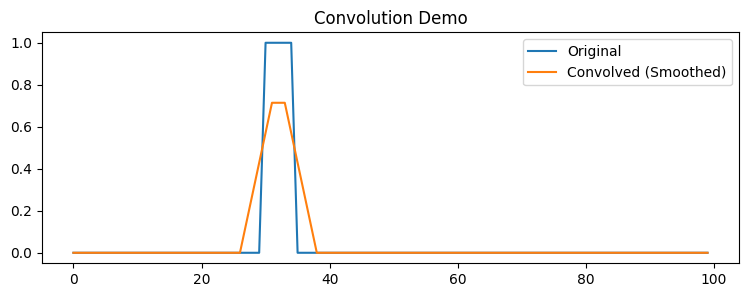

In [2]:
x = np.zeros(100)
x[30:35] = 1  # Simple pulse
kernel = np.ones(7) / 7  # Smoothing kernel
conv_result = convolve_signals(x, kernel)

plt.figure(figsize=(9,3))
plt.plot(x, label='Original')
plt.plot(conv_result, label='Convolved (Smoothed)')
plt.legend(); plt.title('Convolution Demo'); plt.show()


### Autocorrelation Demo (Periodicity Detection)

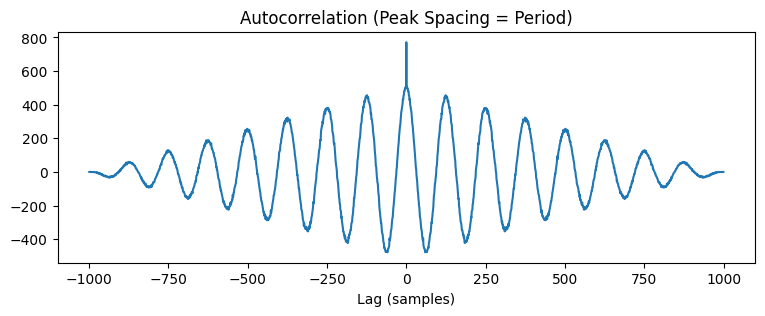

In [3]:
fs = 1000
t = np.linspace(0, 1, fs, endpoint=False)
periodic_signal = np.sin(2*np.pi*8*t) + 0.5*np.random.randn(fs)
auto_corr = autocorrelate_signal(periodic_signal)

lags = np.arange(-len(periodic_signal)+1, len(periodic_signal))
plt.figure(figsize=(9,3))
plt.plot(lags, auto_corr)
plt.title('Autocorrelation (Peak Spacing = Period)')
plt.xlabel('Lag (samples)')
plt.show()


### Cross-correlation Demo (Lag/Peak Finding)

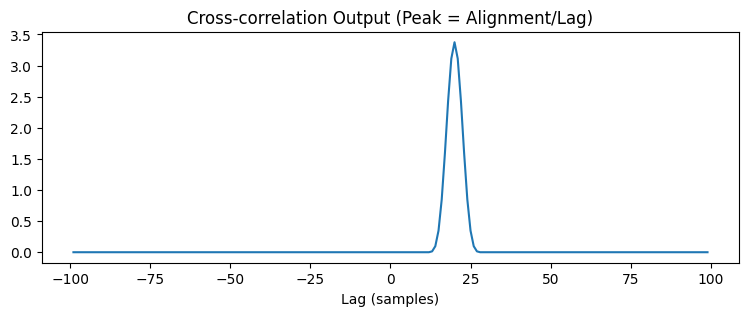

Maximum correlation at lag: 20


In [4]:
sig1 = np.zeros(100)
sig1[40:50] = np.hanning(10)
sig2 = np.zeros(100)
sig2[60:70] = np.hanning(10)  # Delayed version of sig1

cross_corr = crosscorrelate_signals(sig2, sig1)
lags = np.arange(-len(sig1)+1, len(sig1))

plt.figure(figsize=(9,3))
plt.plot(lags, cross_corr)
plt.title('Cross-correlation Output (Peak = Alignment/Lag)')
plt.xlabel('Lag (samples)')
plt.show()

print("Maximum correlation at lag:", lags[np.argmax(cross_corr)])


---
## When to Use What (Quick Reference)

- **Convolution:** Filtering, simulating echo/system response, pulse compression.
- **Autocorrelation:** Detect periodicity, pitch, or repeating patterns in a signal.
- **Cross-correlation:** Find time delay, match templates, synchronize signals, detection.

**In all sonar/DSP pipelines, these are among the most used tools!**
